In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [16]:
df = pd.read_csv("StudentPerformanceFactors.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [17]:
df.fillna(df.mode().iloc[0], inplace=True)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [18]:
level_map = {
    'Low':1,
    'Medium':2,
    'High':3
}

In [19]:
df['Parental_Involvement'] = df['Parental_Involvement'].map(level_map)
df['Motivation_Level'] = df['Motivation_Level'].map(level_map)
df['Family_Income'] = df['Family_Income'].map(level_map)
df['Teacher_Quality'] = df['Teacher_Quality'].map(level_map)
df['Access_to_Resources'] = df['Access_to_Resources'].map(level_map)

In [20]:
yes_no = {
    'Yes':1,
    'No':0
}

df['Internet_Access'] = df['Internet_Access'].map(yes_no)
df['Extracurricular_Activities'] = df['Extracurricular_Activities'].map(yes_no)
df['Learning_Disabilities'] = df['Learning_Disabilities'].map(yes_no)

In [21]:
df['School_Type'] = df['School_Type'].map({
    'Public':0,
    'Private':1
})

In [22]:
corr = df.corr(numeric_only=True)

exam_corr = corr['Exam_Score'].sort_values(ascending=False)

print(exam_corr)

Exam_Score                    1.000000
Attendance                    0.581072
Hours_Studied                 0.445455
Previous_Scores               0.175079
Access_to_Resources           0.169770
Parental_Involvement          0.157114
Tutoring_Sessions             0.156525
Family_Income                 0.094555
Motivation_Level              0.086937
Teacher_Quality               0.076684
Extracurricular_Activities    0.064382
Internet_Access               0.051475
Physical_Activity             0.027824
School_Type                   0.008844
Sleep_Hours                  -0.017022
Learning_Disabilities        -0.085066
Name: Exam_Score, dtype: float64


In [23]:
print(exam_corr.head(6))

Exam_Score              1.000000
Attendance              0.581072
Hours_Studied           0.445455
Previous_Scores         0.175079
Access_to_Resources     0.169770
Parental_Involvement    0.157114
Name: Exam_Score, dtype: float64


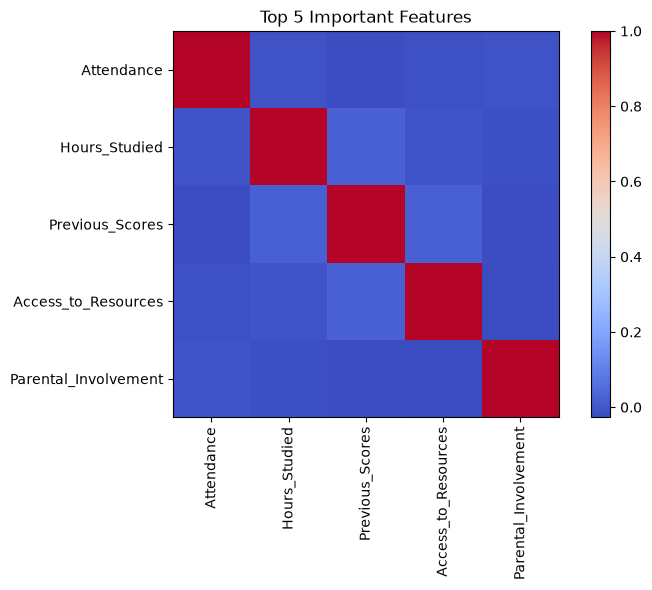

In [24]:
corr = df.corr(numeric_only=True)
top5_features = corr['Exam_Score'].drop('Exam_Score')\
                                  .abs()\
                                  .sort_values(ascending=False)\
                                  .head(5)\
                                  .index
top5_corr = df[top5_features].corr()

plt.figure(figsize=(8,6))

plt.imshow(top5_corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(top5_features)),
           top5_features,
           rotation=90)

plt.yticks(range(len(top5_features)),
           top5_features)

plt.title("Top 5 Important Features")

plt.tight_layout()
plt.show()

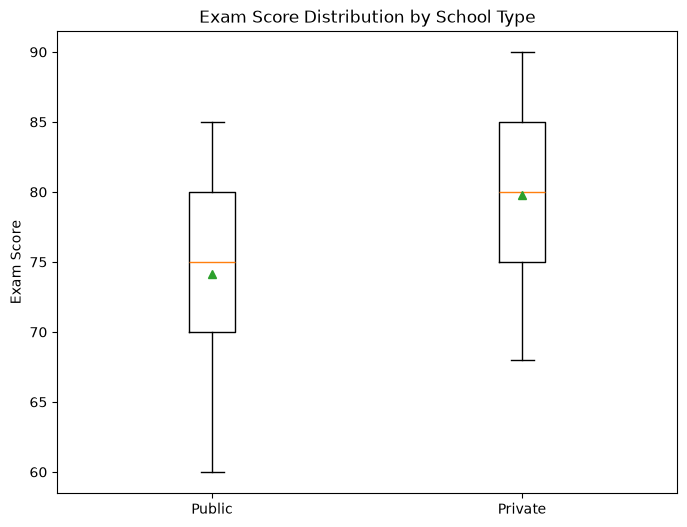

In [25]:
public_scores = [60, 65, 70, 72, 75, 78, 80, 82, 85]
private_scores = [68, 72, 75, 77, 80, 83, 85, 88, 90]

plt.figure(figsize=(8,6))

plt.boxplot(
    [public_scores, private_scores],
    tick_labels=['Public', 'Private'],
    showmeans=True
)

plt.title("Exam Score Distribution by School Type")
plt.ylabel("Exam Score")

plt.show()

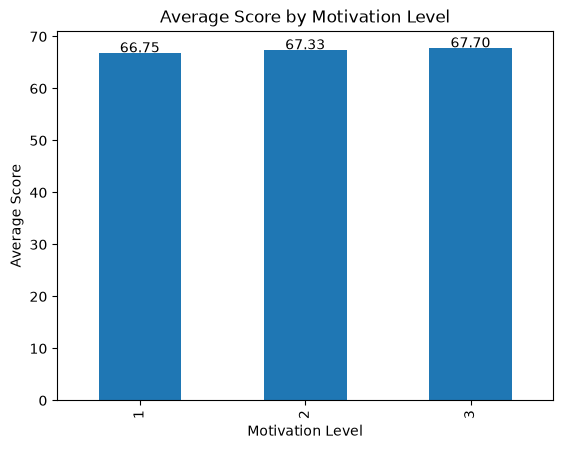

In [26]:
motivation_avg = df.groupby('Motivation_Level')['Exam_Score'].mean()

ax = motivation_avg.plot(kind='bar')
for i, value in enumerate(motivation_avg):
    plt.text(i, value + 0.2, f'{value:.2f}', ha='center')

plt.title("Average Score by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Average Score")

plt.show()

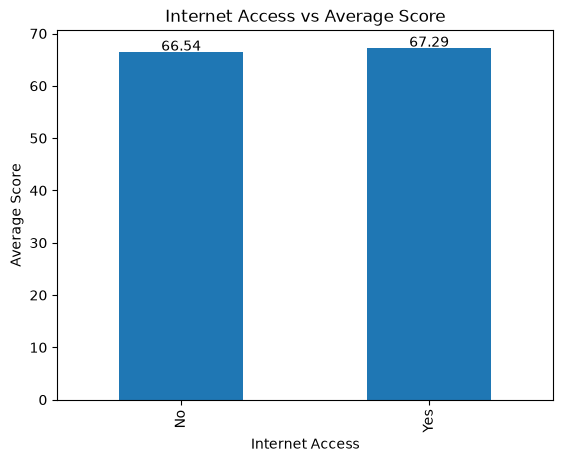

In [27]:
internet_avg = df.groupby('Internet_Access')['Exam_Score'].mean()

ax = internet_avg.plot(kind='bar')
for i, value in enumerate(internet_avg):
    plt.text(i, value + 0.2, f'{value:.2f}', ha='center')

plt.title("Internet Access vs Average Score")
plt.xlabel("Internet Access")
plt.ylabel("Average Score")

plt.xticks([0, 1], ['No', 'Yes'])

plt.show()

In [28]:
parent_avg = df.groupby('Parental_Involvement')['Exam_Score'].mean()

print(parent_avg)

print("\nCONCLUSION")
print("1. Previous_Scores has the strongest impact on Exam_Score.")
print("2. Hours_Studied and Access to Resources significantly influence student performance.")
print("3. Tutoring_Sessions also contribute positively to exam results.")
print("Overall, academic effort and prior performance are the most important factors affecting Exam_Score.")

Parental_Involvement
1    66.358265
2    67.098156
3    68.092767
Name: Exam_Score, dtype: float64

CONCLUSION
1. Previous_Scores has the strongest impact on Exam_Score.
2. Hours_Studied and Access to Resources significantly influence student performance.
3. Tutoring_Sessions also contribute positively to exam results.
Overall, academic effort and prior performance are the most important factors affecting Exam_Score.
